In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [2]:
combined = pd.read_csv('/kaggle/input/employee-data-simulation-it-industry/employee_data.csv')
combined.head()

,ID,Gender,Experience (Years),Position,Salary
0,1,F,4,DevOps Engineer,109976
1,2,M,6,DevOps Engineer,120088
2,3,M,17,Web Developer,181301
3,4,M,7,Systems Administrator,77530
4,5,F,13,Systems Administrator,152397


In [3]:
rows, cols = combined.shape
print(F"Number of rows: {rows}")
print(F"Number of columns: {cols}")

def variable_type(col):
    if combined[col].dtype == 'object':
        return 'Categorical'
    elif combined[col].nunique() / rows < 0.05:
        return ' Categorical'
    else:
        return 'Continous'
variable_type = combined.columns.to_series().apply(variable_type)
print("Variable Types:\n", variable_type)

Number of rows: 400
Number of columns: 5
Variable Types:
 ID                      Continous
Gender                Categorical
Experience (Years)      Continous
Position              Categorical
Salary                  Continous
dtype: object


In [4]:
numerical_columns = combined.select_dtypes(include='number')

five_point_summary = numerical_columns.describe(percentiles=[0.25,0.5,0.75]).loc[['min','25%','50%','75%','max']]
print("Five-point summary:\n", five_point_summary)

Five-point summary:
          ID  Experience (Years)     Salary
min    1.00                 0.0   43643.00
25%  100.75                 4.0  100484.75
50%  200.50                10.0  128561.50
75%  300.25                15.0  157735.00
max  400.00                20.0  269950.00


In [6]:
categorical_columns = combined.select_dtypes(include='object')
def summarize_categorical (column):
    count = column.value_counts()
    Percentage = column.value_counts(normalize=True)*100
    summary = pd.DataFrame({"Count": count, 'Percentage': Percentage})
    return summary

categorical_summary = {col: summarize_categorical(combined[col]) for col in categorical_columns}

for col, summary in categorical_summary.items():
    print(F"Summary for {col}:\n{summary}\n")

Summary for Gender:
        Count  Percentage
Gender                   
M         202        50.5
F         198        49.5

Summary for Position:
                              Count  Percentage
Position                                       
Web Developer                    43       10.75
IT Manager                       40       10.00
IT Security Analyst              39        9.75
Systems Administrator            38        9.50
Database Administrator (DBA)     38        9.50
DevOps Engineer                  37        9.25
Systems Analyst                  37        9.25
Software Engineer                36        9.00
Network Administrator            31        7.75
IT Support Specialist            31        7.75
Cloud Solutions Architect        30        7.50



In [7]:
missing_values = combined.isnull().sum()
missing_percentage = (combined.isnull().sum() /len(combined))*100
missing_data_summary = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
print("Missing values summary:\n", missing_data_summary)

def detect_outliers(combined):
    outliers = pd.DataFrame(columns=combined.columns)
    for col in combined.select_dtypes(include=np.number).columns:
        Q1 = combined[col].quantile(0.25)
        Q3 = combined[col].quantile(0.75)
        IQR = Q3-Q1
        lower_bound = Q1 - 1.5*IQR
        upper_bound = Q3 + 1.5*IQR
        outlier_condition = (combined[col] < lower_bound)| (combined[col] > upper_bound)
        outliers[col] = outlier_condition
    return outliers

outliers = detect_outliers(combined)
outliers_summary = outliers.sum()
print("Outliers Summary:\n", outliers_summary)

class_counts = combined['Salary'].value_counts()
class_percentage = combined['Salary'].value_counts(normalize=True)*100
class_imbalance_summary = pd.DataFrame({'Count': class_counts, 'Percenatge': class_percentage})
print("Class Imbalbance summary:\n", class_imbalance_summary)
        

Missing values summary:
                     Missing Values  Percentage
ID                               0         0.0
Gender                           0         0.0
Experience (Years)               0         0.0
Position                         0         0.0
Salary                           0         0.0
Outliers Summary:
 ID                    0
Gender                0
Experience (Years)    0
Position              0
Salary                5
dtype: object
Class Imbalbance summary:
         Count  Percenatge
Salary                   
109976      1        0.25
92927       1        0.25
132311      1        0.25
161927      1        0.25
79944       1        0.25
...       ...         ...
155017      1        0.25
95631       1        0.25
120142      1        0.25
90393       1        0.25
169058      1        0.25

[400 rows x 2 columns]


In [8]:
combined.head()

,ID,Gender,Experience (Years),Position,Salary
0,1,F,4,DevOps Engineer,109976
1,2,M,6,DevOps Engineer,120088
2,3,M,17,Web Developer,181301
3,4,M,7,Systems Administrator,77530
4,5,F,13,Systems Administrator,152397


In [9]:
from sklearn.impute import SimpleImputer
from sklearn.utils import resample

imputer_mean = SimpleImputer(strategy='mean')
combined[combined.select_dtypes(include=np.number).columns] = imputer_mean.fit_transform(combined.select_dtypes(include='number'))


def cap_outliers (combined):
     for col in combined.select_dtypes(include=np.number).columns:
        Q1 = combined[col].quantile(0.25)
        Q3 = combined[col].quantile(0.75)
        IQR = Q3-Q1
        lower_bound = Q1 - 1.5*IQR
        upper_bound = Q3 + 1.5*IQR
        combined[col] = np.where(combined[col] < lower_bound, lower_bound, combined[col])
        combined[col] = np.where(combined[col] > upper_bound, upper_bound, combined[col])
        
        
        return combined


combined = cap_outliers(combined)

combined_majority = combined[combined['ID'] == combined['ID'] . value_counts().idxmax()]
combined_minority = combined[combined['ID'] == combined['ID'].value_counts().idxmin()]

combined_minority_upsampled = resample(combined_minority,
                                      replace=True,
                                      n_samples=len(combined_majority),
                                      random_state=42)

combined_balanced = pd.concat([combined_majority, combined_minority_upsampled])
print("Class counts after balancing:\n", combined_balanced['ID'].value_counts())


Class counts after balancing:
 ID
1.0    2
Name: count, dtype: int64


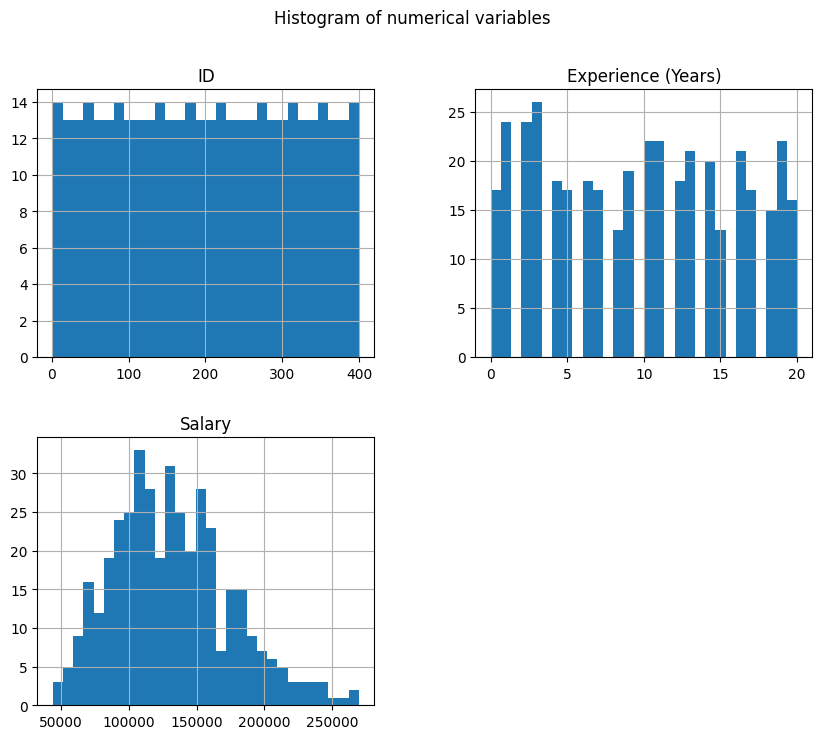

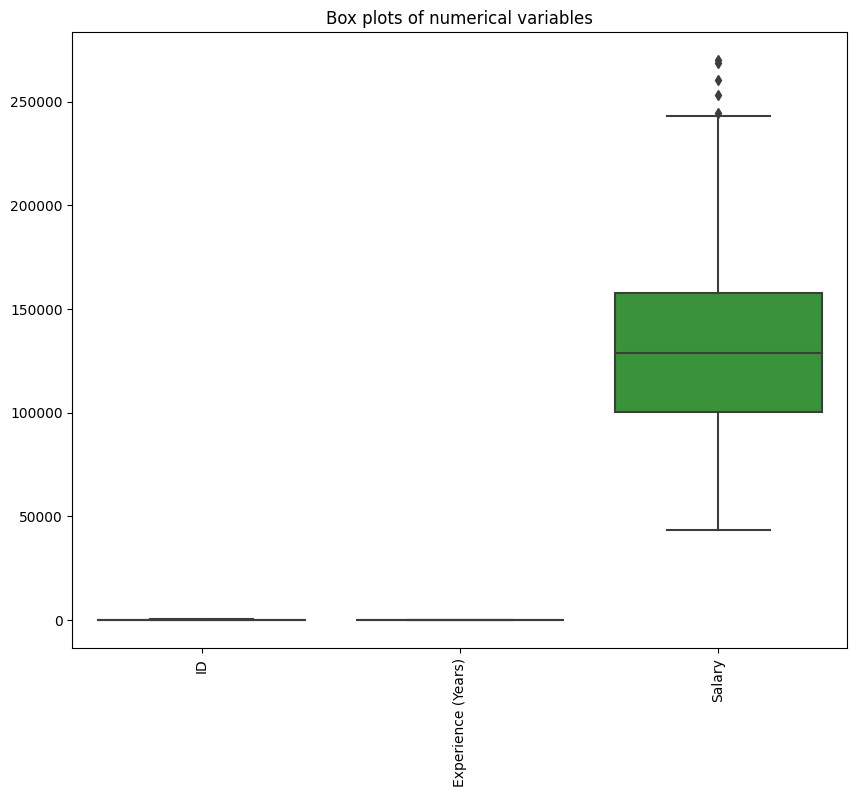

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


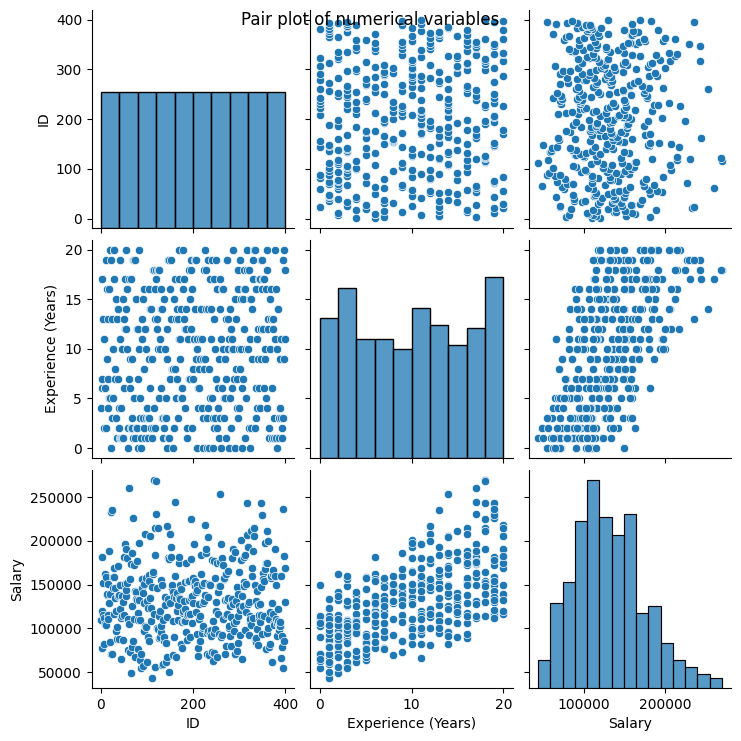

ValueError: could not convert string to float: 'F'

In [10]:
combined .hist(figsize=(10,8), bins=30)
plt.suptitle("Histogram of numerical variables")
plt.show()

plt.figure(figsize=(10,8))
sns.boxplot(data=combined.select_dtypes(include='number'))
plt.title("Box plots of numerical variables")
plt.xticks(rotation=90)
plt.show()

sns.pairplot(combined.select_dtypes(include='number'))
plt.suptitle("Pair plot of numerical variables")
plt.show()

correlation_matrix = combined.corr()
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap")
plt.show()

target_corr = correlation_matrix['Salary'].sort_values(ascending=False)
high_corr_vars = target_corr[abs(target_corr) >0.5]
print("Variables highly correlated with target:\n", high_corr_vars)

for var in high_corr_vars.index:
    if var != 'Salary':
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=combined[var], y=combined['Salary'])
        plt.title(f'Scatter plot: {var} vs target')
        plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import  ColumnTransformer

categorical_columns = combined.select_dtypes(include=['object','category']).columns

print("Categorical columns:", categorical_columns.tolist())

label_encoder = LabelEncoder()
for col in categorical_columns:
    combined[col] = label_encoder.fit_transform(combined[col])

combined_onehot = pd.get_dummies(combined, columns=categorical_columns, drop_first=True)
print("One-hot Encoded data:\n", combined_onehot.head())

column_transformer = ColumnTransformer(
transformers=[
    ('onehot', OneHotEncoder, categorical_columns)
    
],
remainder='passthrough')
df_transformed = column_transformer.fit_transform(combined)
df_transformed = pd.DataFrame(df_transformed, columns=column_transformer.get_feature_names_out())
print("Column transformer one-hot encoded data:\n", df_transformed.head())

for col in categorical_columns:
    freq_encoding = df[col].value_counts() / len(df)
    df[col] = df[col].map(freq_encoding)
print("frequency Encoded data:\n", combined.head())




Categorical columns: []
One-hot Encoded data:
     ID  Gender  Experience (Years)  Position    Salary
0  1.0       0                 4.0         2  109976.0
1  2.0       1                 6.0         2  120088.0
2  3.0       1                17.0        10  181301.0
3  4.0       1                 7.0         8   77530.0
4  5.0       0                13.0         8  152397.0
Column transformer one-hot encoded data:
    remainder__ID  remainder__Gender  remainder__Experience (Years)  \
0            1.0                0.0                            4.0   
1            2.0                1.0                            6.0   
2            3.0                1.0                           17.0   
3            4.0                1.0                            7.0   
4            5.0                0.0                           13.0   

   remainder__Position  remainder__Salary  
0                  2.0           109976.0  
1                  2.0           120088.0  
2                 10.0      

Training set statistics:
               ID      Gender  Experience (Years)    Position
count  280.000000  280.000000          280.000000  280.000000
mean   203.928571    0.507143            9.971429    5.096429
std    111.988168    0.500844            6.170740    3.139753
min      2.000000    0.000000            0.000000    0.000000
25%    111.500000    0.000000            4.000000    2.750000
50%    203.000000    1.000000           10.500000    5.000000
75%    303.250000    1.000000           15.000000    8.000000
max    400.000000    1.000000           20.000000   10.000000

testing set statistics:
               ID      Gender  Experience (Years)    Position
count  120.000000  120.000000          120.000000  120.000000
mean   192.500000    0.500000            8.966667    5.175000
std    123.781184    0.502096            5.902475    3.327155
min      1.000000    0.000000            0.000000    0.000000
25%     78.750000    0.000000            4.000000    2.000000
50%    181.500000   

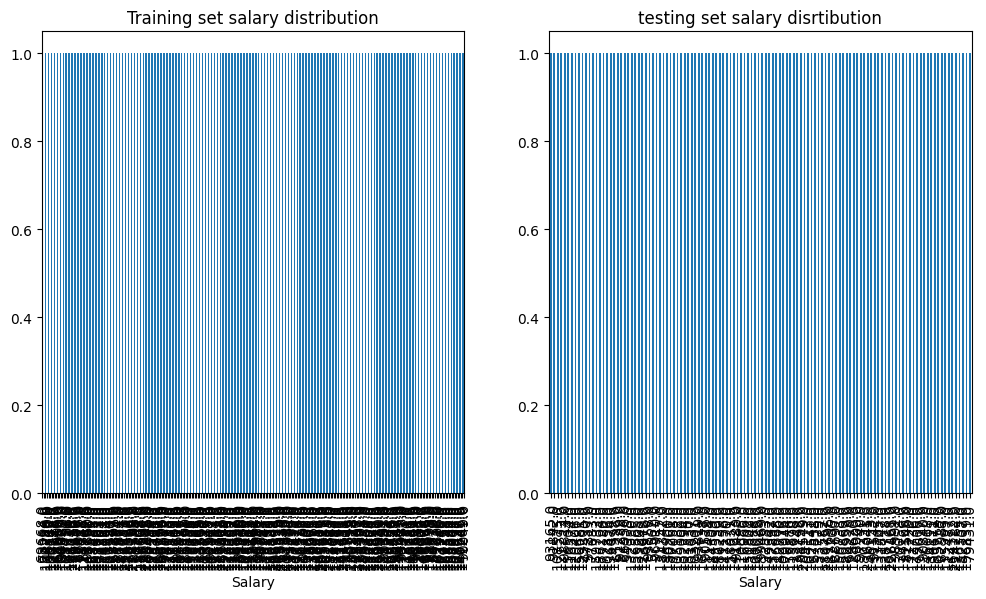

Feature: ID, ks Statistics: 0.11190476190476191, p-value: 0.22729506490124002
Feature: Gender, ks Statistics: 0.007142857142857143, p-value: 1.0
Feature: Experience (Years), ks Statistics: 0.125, p-value: 0.13386160622540902
Feature: Position, ks Statistics: 0.05714285714285714, p-value: 0.9328301663669996


In [20]:
from sklearn.model_selection import train_test_split
from scipy.stats import ks_2samp, chi2_contingency

x = combined.drop(columns='Salary')
y = combined['Salary']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

print("Training set statistics:")
print(x_train.describe(include='all'))
print("\ntesting set statistics:")
print(x_test.describe(include='all'))

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
y_train.value_counts().plot(kind='bar')
plt.title('Training set salary distribution')

plt.subplot(1,2,2)
y_test.value_counts().plot(kind='bar')
plt.title('testing set salary disrtibution')

plt.show()

def ks_test(feature_name):
    stat, p_value = ks_2samp(x_train[feature_name], x_test[feature_name])
    return stat, p_value
for feature in x.select_dtypes(include=[np.number]).columns:
    stat, p_value = ks_test(feature)
    print(f"Feature: {feature}, ks Statistics: {stat}, p-value: {p_value}")

def chi2_test(feature_name):
    contingency_table = pd.crosstab(x_train[feature_name], x_test[feature_name])
    stat, p_value,_, _ = chi2_contingency(contingency_table)
    return stat, p_value

for feature in x.select_dtypes(include=['object']).columns:
    stat, p_value = chi2_test(feature)
    print(F"Feature: {feature}, chi-square statistics: {stat}, p-value: {p_value}")

In [12]:
combined.head()

,ID,Gender,Experience (Years),Position,Salary
0,1.0,F,4.0,DevOps Engineer,109976.0
1,2.0,M,6.0,DevOps Engineer,120088.0
2,3.0,M,17.0,Web Developer,181301.0
3,4.0,M,7.0,Systems Administrator,77530.0
4,5.0,F,13.0,Systems Administrator,152397.0


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score




numerical_vars = x.select_dtypes(include=['float64','int64'])
scaler = StandardScaler()
x[numerical_vars.columns] = scaler.fit_transform(numerical_vars)

categorical_vars = x.select_dtypes(include=['object','category'])
x_encoded = pd.get_dummies(x, columns=categorical_vars.columns, drop_first=True)

x_train,x_test,y_train,y_test = train_test_split(x_encoded,y, test_size=0.3, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test,y_pred)
report = classification_report(y_test,y_pred)

print(F"Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(report)

Model Accuracy: 0.00

Classification Report:
              precision    recall  f1-score   support

     48710.0       0.00      0.00      0.00       0.0
     54938.0       0.00      0.00      0.00       1.0
     57567.0       0.00      0.00      0.00       1.0
     57838.0       0.00      0.00      0.00       1.0
     61236.0       0.00      0.00      0.00       1.0
     61605.0       0.00      0.00      0.00       0.0
     62301.0       0.00      0.00      0.00       0.0
     64220.0       0.00      0.00      0.00       1.0
     64736.0       0.00      0.00      0.00       0.0
     66076.0       0.00      0.00      0.00       0.0
     66956.0       0.00      0.00      0.00       1.0
     68000.0       0.00      0.00      0.00       1.0
     71211.0       0.00      0.00      0.00       0.0
     71220.0       0.00      0.00      0.00       1.0
     71389.0       0.00      0.00      0.00       0.0
     75749.0       0.00      0.00      0.00       0.0
     77058.0       0.00      0.00   

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

numerical_vars = x.select_dtypes(include=['float64','int64'])
scaler = StandardScaler()
x[numerical_vars.columns] = scaler.fit_transform(numerical_vars)

categorical_vars = x.select_dtypes(include=['object','category'])
x_encoded = pd.get_dummies(x, columns=categorical_vars.columns, drop_first=True)

x_train,x_test,y_train,y_test = train_test_split(x_encoded,y, test_size=0.3, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test,y_pred)
print(F"overall accuaracy: {accuracy:.2f}")

if accuracy> 0.90:
    print("The model accuracy is excellent. it performs very well on the test data.")
elif accuracy> 0.80:
    print("The model accuracy is good, but there may be room for improvement.")
elif accuracy > 0.70:
    print("The model accuracy is acceptable, though there might be issues or room for further optimization.")
else:
    print("The model accuracy is low. consider revisiting the model or feature engineering.")





overall accuaracy: 0.00
The model accuracy is low. consider revisiting the model or feature engineering.


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

numerical_vars = x.select_dtypes(include=['float64','int64'])
scaler = StandardScaler()
x[numerical_vars.columns] = scaler.fit_transform(numerical_vars)

categorical_vars = x.select_dtypes(include=['object','category'])
x_encoded = pd.get_dummies(x, columns=categorical_vars.columns, drop_first=True)

x_train,x_test,y_train,y_test = train_test_split(x_encoded,y, test_size=0.3, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

precision = precision_score(y_test,y_pred, average='weighted')
recall = recall_score(y_test,y_pred, average='weighted')
f1 = f1_score(y_test,y_pred, average='weighted')

print(F"precision : {precision:.2f}")
print(F"Recall : {recall:.2f}")
print(F"f1 Score: {f1:.2f}")

report = classification_report(y_test,y_pred)
print("\nClassification Report:")
print(report)


precision : 0.00
Recall : 0.00
f1 Score: 0.00

Classification Report:
              precision    recall  f1-score   support

     48710.0       0.00      0.00      0.00       0.0
     54938.0       0.00      0.00      0.00       1.0
     57567.0       0.00      0.00      0.00       1.0
     57838.0       0.00      0.00      0.00       1.0
     61236.0       0.00      0.00      0.00       1.0
     61605.0       0.00      0.00      0.00       0.0
     62301.0       0.00      0.00      0.00       0.0
     64220.0       0.00      0.00      0.00       1.0
     64736.0       0.00      0.00      0.00       0.0
     66076.0       0.00      0.00      0.00       0.0
     66956.0       0.00      0.00      0.00       1.0
     68000.0       0.00      0.00      0.00       1.0
     71211.0       0.00      0.00      0.00       0.0
     71220.0       0.00      0.00      0.00       1.0
     71389.0       0.00      0.00      0.00       0.0
     75749.0       0.00      0.00      0.00       0.0
     77058.

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWa

In [25]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

numerical_vars = x.select_dtypes(include=['float64','int64'])
scaler = StandardScaler()
x[numerical_vars.columns] = scaler.fit_transform(numerical_vars)

categorical_vars = x.select_dtypes(include=['object','category'])
x_encoded = pd.get_dummies(x, columns=categorical_vars.columns, drop_first=True)

x_train,x_test,y_train,y_test = train_test_split(x_encoded,y, test_size=0.3, random_state=42)
smote = SMOTE(random_state=42)
x_reampled, y_resampled = (x_train,y_train)


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

numerical_vars = x.select_dtypes(include=['float64','int64'])
scaler = StandardScaler()
x[numerical_vars.columns] = scaler.fit_transform(numerical_vars)

categorical_vars = x.select_dtypes(include=['object','category'])
x_encoded = pd.get_dummies(x, columns=categorical_vars.columns, drop_first=True)

x_train,x_test,y_train,y_test = train_test_split(x_encoded,y, test_size=0.3, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train,y_train)

feature_importances = model.feature_importances_
features = x_encoded.columns

importance_df = pd.DataFrame({
    'feature': features,
    'Importance' : feature_importances
    
}).sort_values(by='Importance', ascending=False)

print("Top Features:")
print(importance_df.head(10))


Top Features:
              feature  Importance
0                  ID    0.442604
2  Experience (Years)    0.273214
3            Position    0.200121
1              Gender    0.084060


<Axes: >

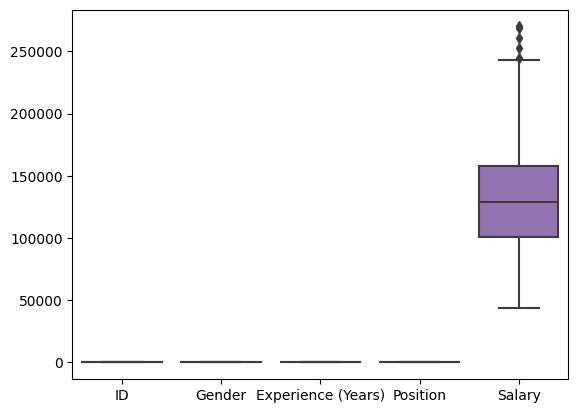

In [32]:
sns.boxplot(combined)

<Axes: >

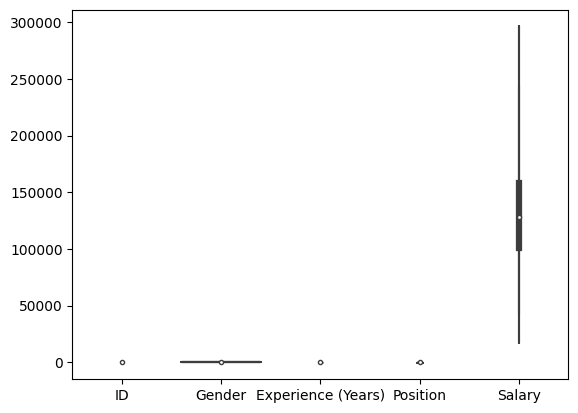

In [33]:
sns.violinplot(combined)

<Axes: >

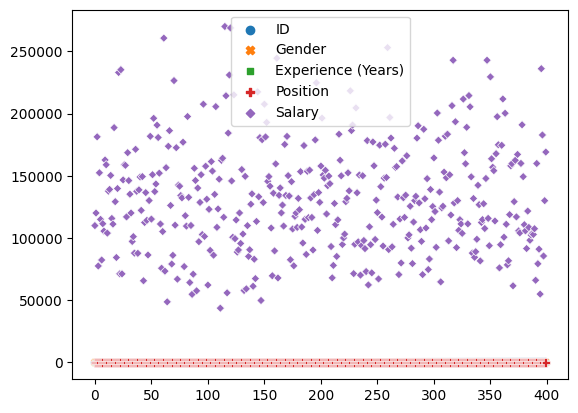

In [34]:
sns.scatterplot(combined)

<Axes: >

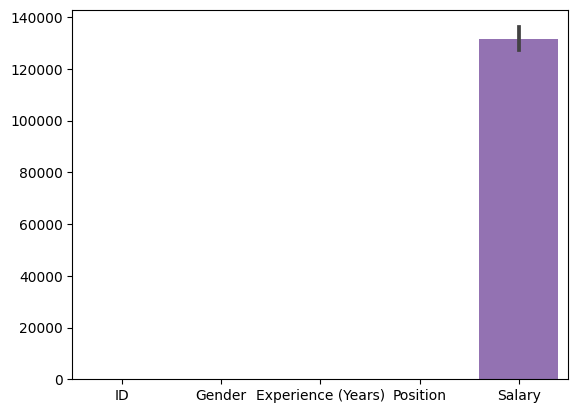

In [36]:
sns.barplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: ylabel='Density'>

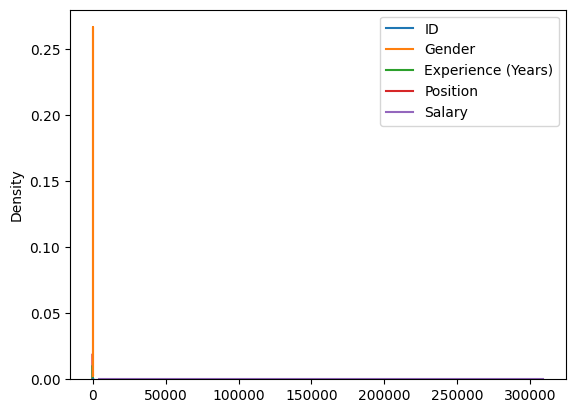

In [37]:
sns.kdeplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

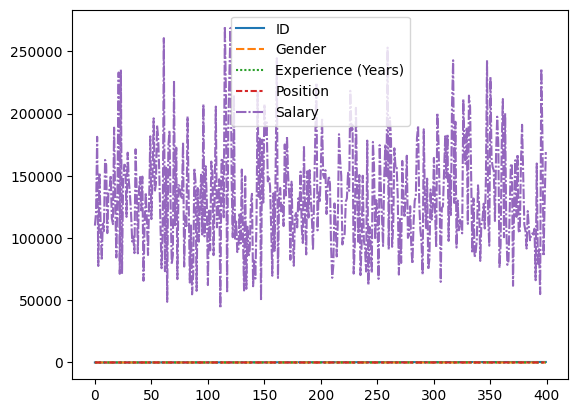

In [38]:
sns.lineplot(combined)

<Axes: ylabel='count'>

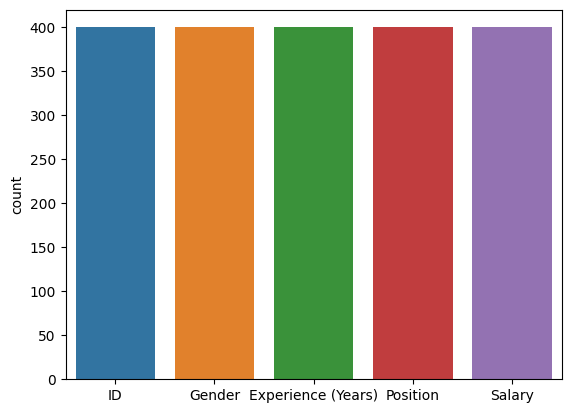

In [39]:
sns.countplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

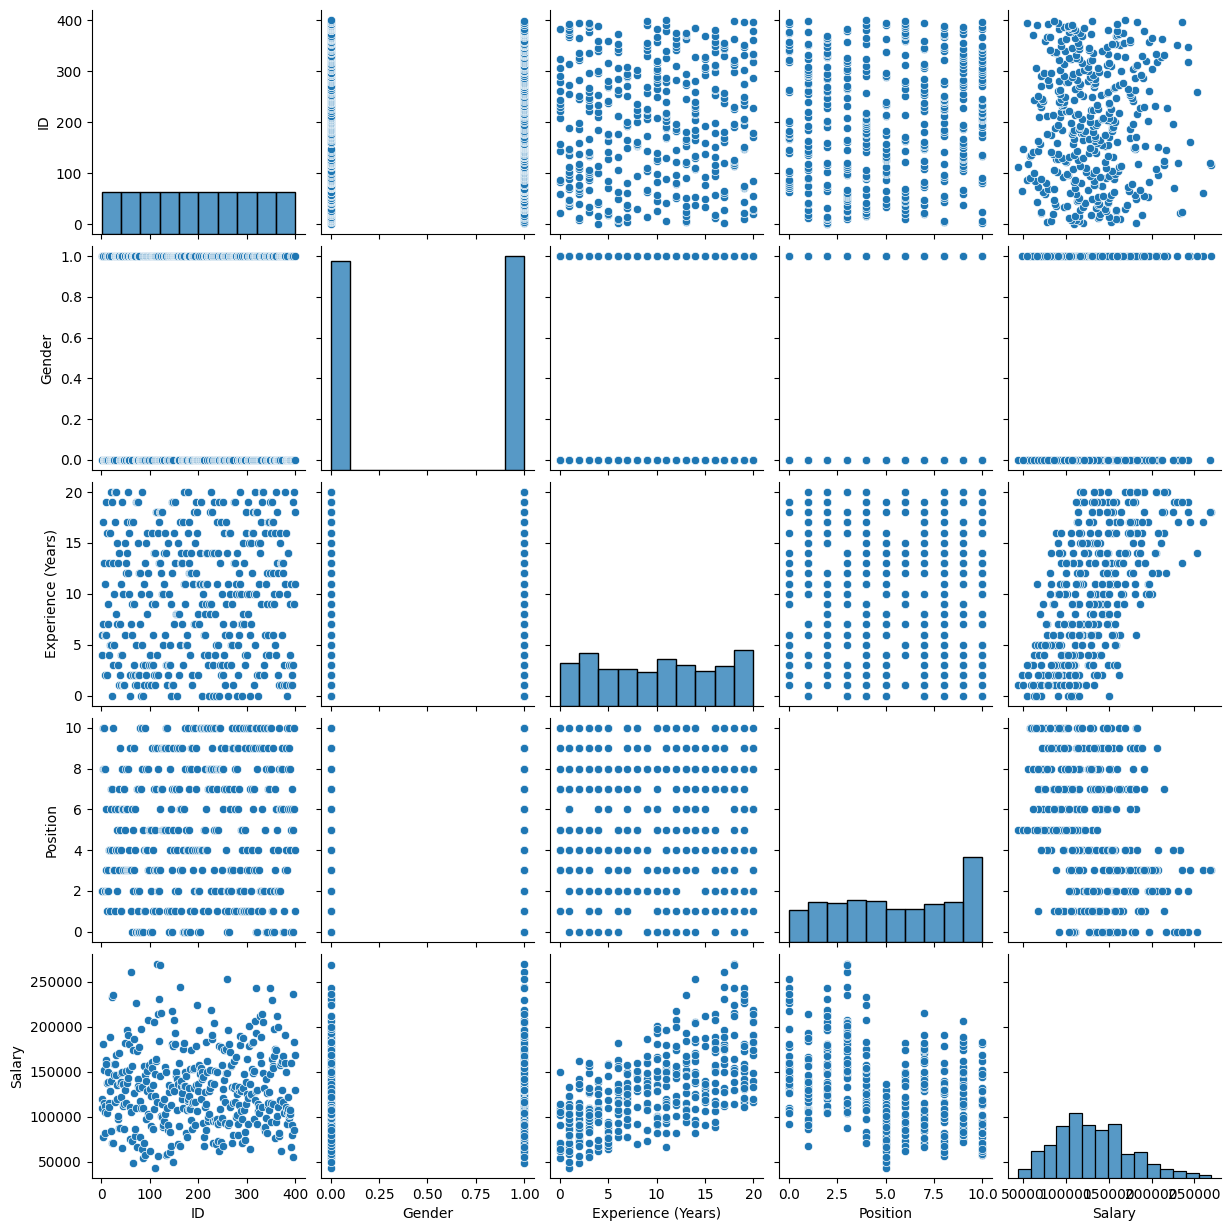

In [40]:
sns.pairplot(combined)

<Axes: >

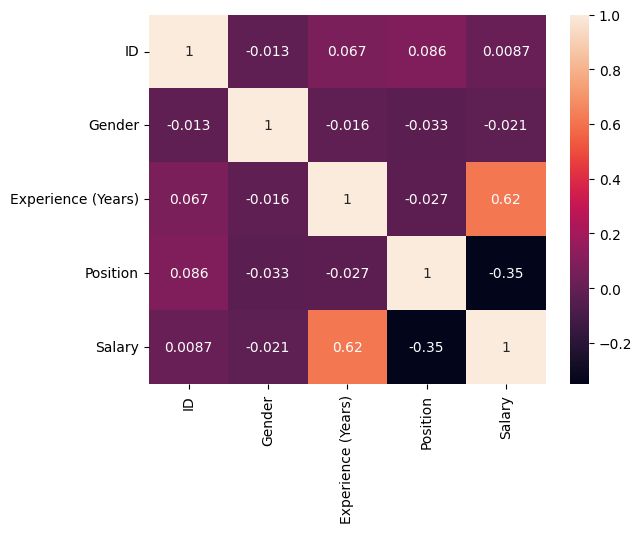

In [42]:
sns.heatmap(combined.corr(),annot=True)

In [44]:
cat_cols = combined.select_dtypes(include='object')

In [45]:
for i in cat_cols:
    print(i)
    (combined[i].value_counts())
    print('\n')
    print(''*50)

In [46]:
num_cols = combined.select_dtypes(include='number')

In [47]:
for i in num_cols:
    print(i)
    (combined[i].value_counts())
    print('\n')
    print(''*50)

ID



Gender



Experience (Years)



Position



Salary





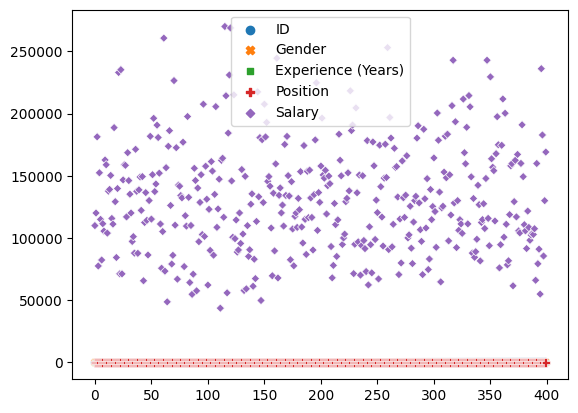

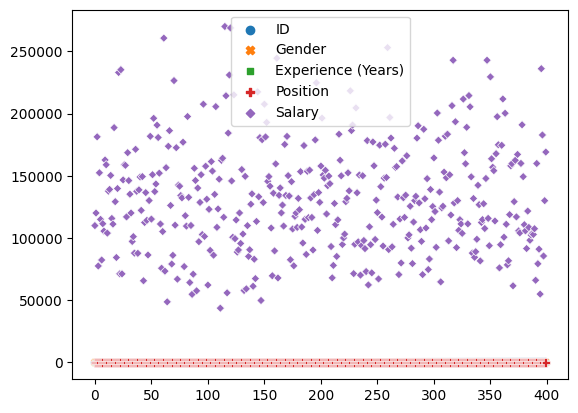

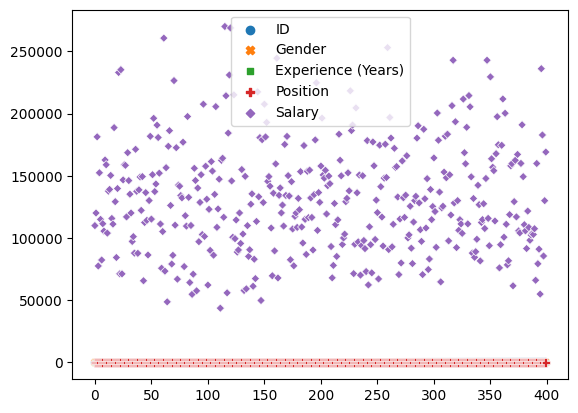

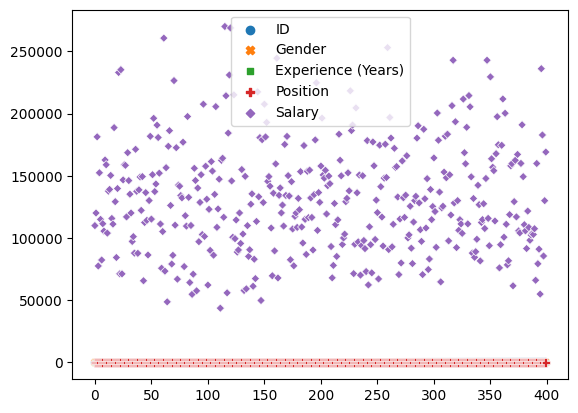

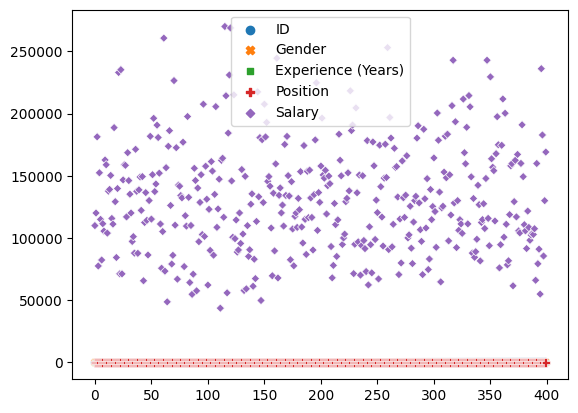

In [50]:
x = 1
num_cols = combined.select_dtypes(include='number')
for i in num_cols:
    sns.scatterplot(data=combined)
    print('\n')
    plt.show()

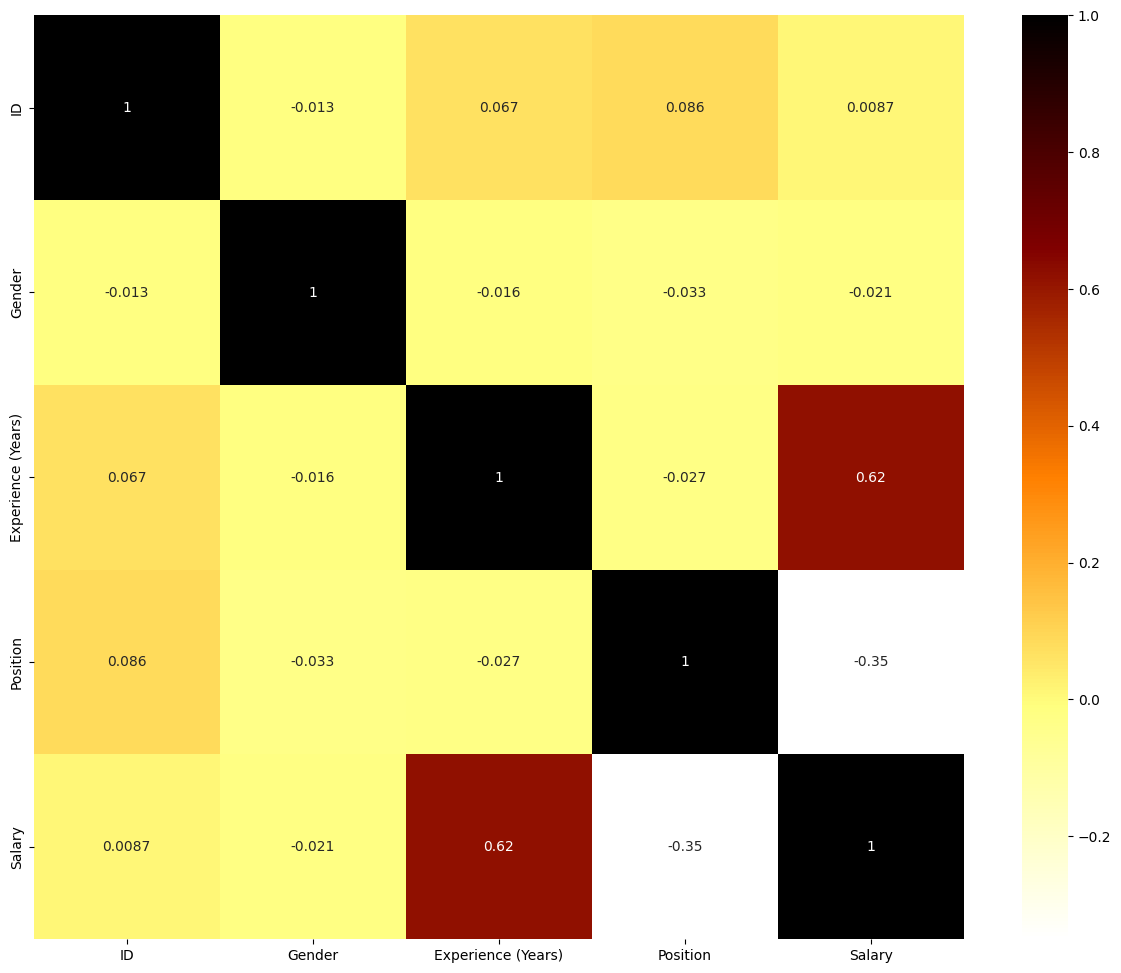

In [52]:
plt.figure(figsize=(15,12))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

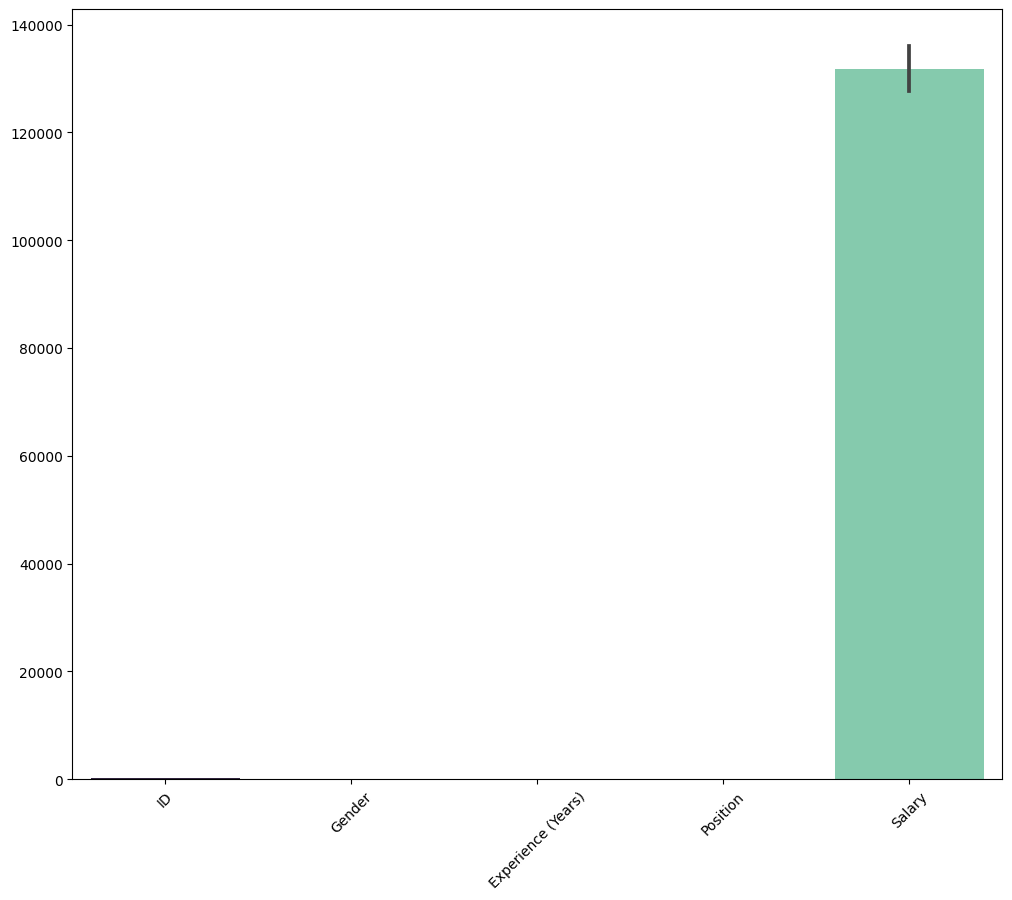

In [54]:
plt.figure(figsize=(12,10))
sns.barplot(data=combined,palette='mako');
plt.xticks(rotation=45);
plt.show()

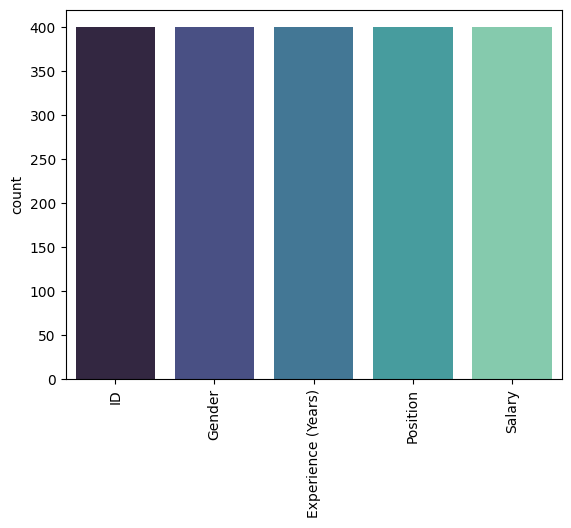

In [55]:
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=90);
plt.show() 

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

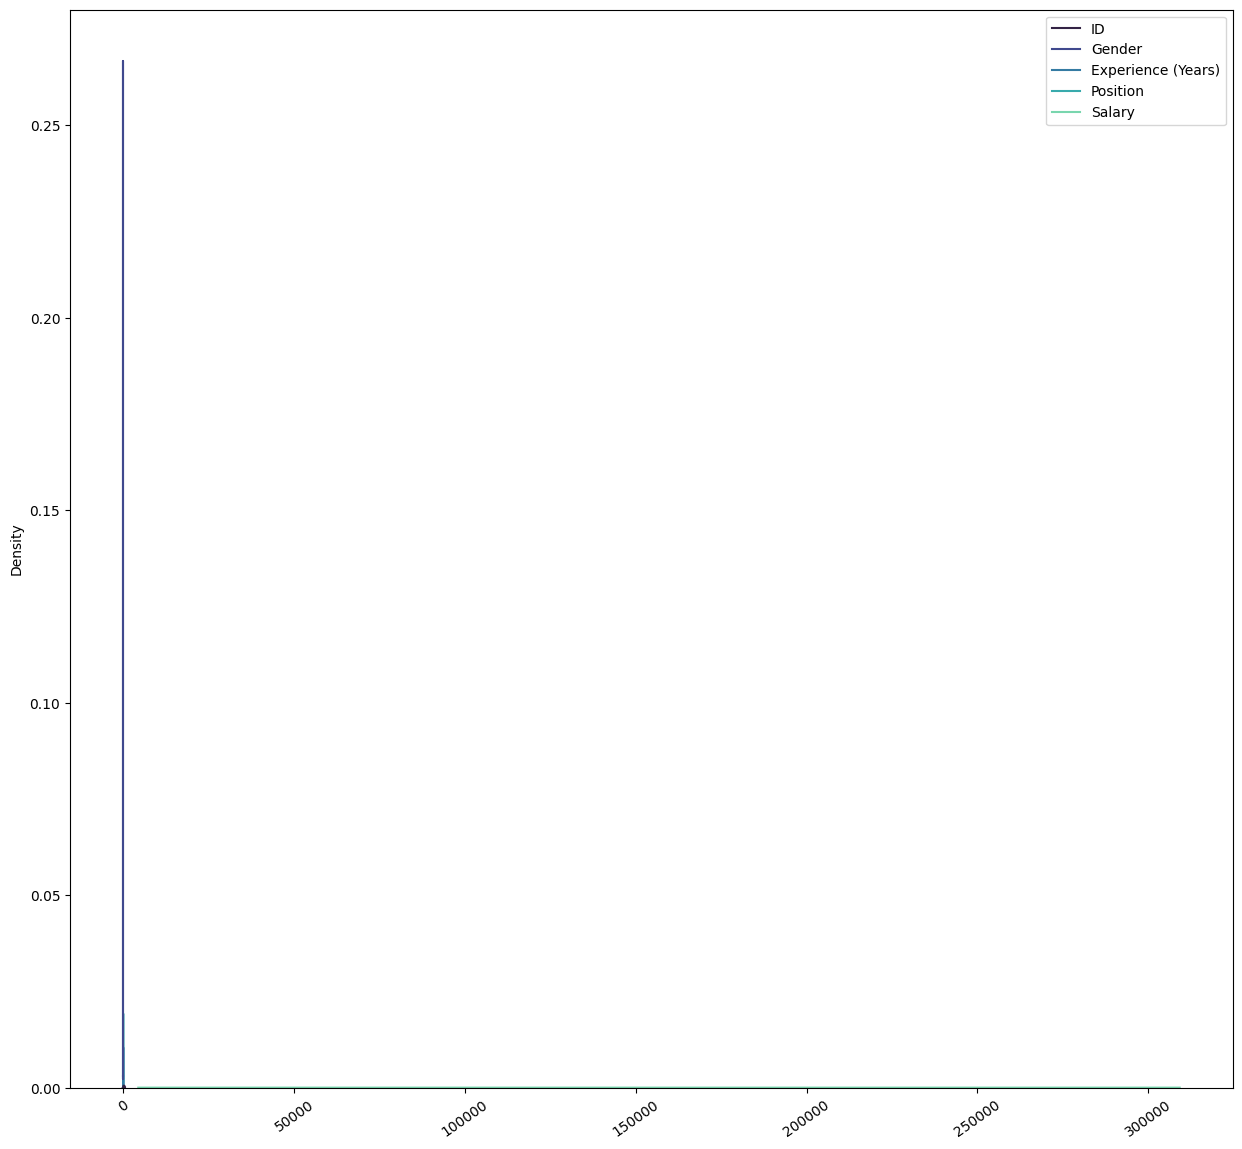

In [56]:
plt.figure(figsize=(15,14))
sns.kdeplot(data=combined,palette='mako');
plt.xticks(rotation=35);
plt.show()

In [57]:
combined.head()

,ID,Gender,Experience (Years),Position,Salary
0,1.0,0,4.0,2,109976.0
1,2.0,1,6.0,2,120088.0
2,3.0,1,17.0,10,181301.0
3,4.0,1,7.0,8,77530.0
4,5.0,0,13.0,8,152397.0


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


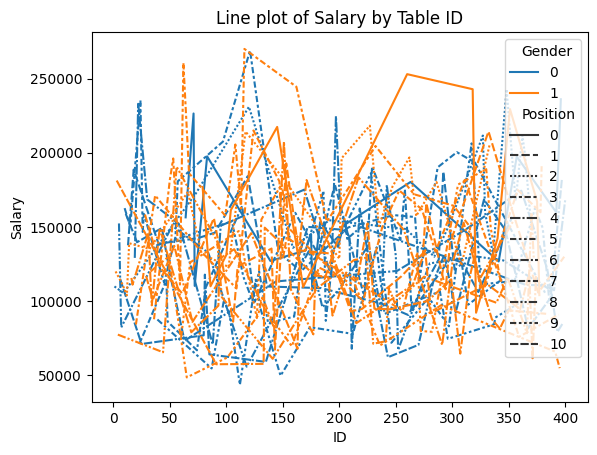

In [58]:
sns.lineplot(x='ID', y='Salary', data=combined, hue='Gender',style='Position')
plt.title("Line plot of Salary by Table ID")
plt.show()

In [60]:
import plotly.express as px
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
import warnings
warnings.filterwarnings('ignore')

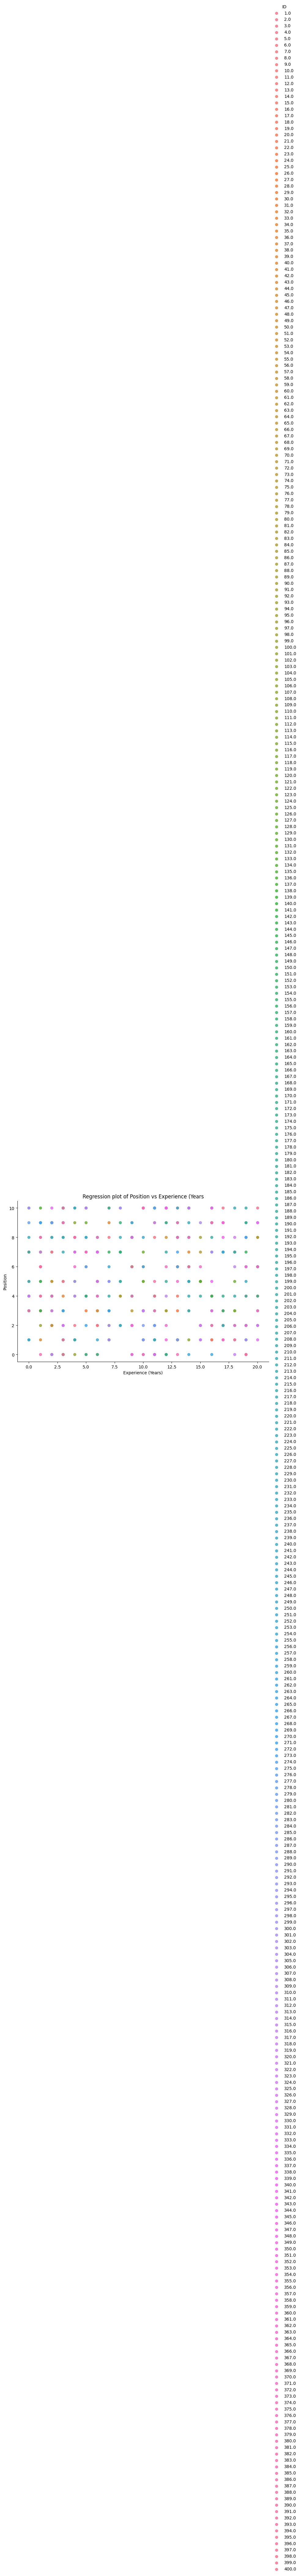

In [62]:
sns.lmplot(x='Experience (Years)', y='Position', data=combined, hue='ID', height=6, aspect=1.5)
plt.title("Regression plot of Position vs Experience (Years")
plt.show()